# 05 – Results Comparison

Side-by-side comparison of Isolation Forest and Autoencoder.

In [5]:
import sys, os; sys.path.insert(0, os.path.abspath('..'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay
from src.utils.preprocessing import (
    generate_synthetic_dataset, preprocess_pipeline, FEATURE_COLUMNS,
    build_feature_weights,
)
from src.models.isolation_forest import SatelliteIsolationForest
from src.models.autoencoder import SatelliteAutoencoder


def make_windows(frame, cols, window_size=12, center_label=True):
    values = frame[cols].values
    labels = frame['label'].values if 'label' in frame.columns else None
    windows, y = [], []
    half = window_size // 2
    for end in range(window_size, len(frame) + 1):
        start = end - window_size
        windows.append(values[start:end].reshape(-1))
        if labels is not None:
            if center_label:
                y.append(labels[start + half])
            else:
                y.append(labels[start:end].max())
    return np.asarray(windows, dtype=np.float32), (np.asarray(y, dtype=int) if labels is not None else None)


df = generate_synthetic_dataset(n_samples=120_000, seed=42)
feature_cols = [c for c in FEATURE_COLUMNS if c in df.columns]
train, val, test, scaler, all_feature_cols = preprocess_pipeline(df, feature_cols)

# Isolation Forest: pointwise on base features
X_train_if = train[feature_cols].values
X_test_if = test[feature_cols].values
y_test_if = test['label'].values

# Autoencoder: sequence windows on curated features
seq_cols = [c for c in all_feature_cols if c in train.columns
            and '_roll_mean' not in c and '_roll_std' not in c]
window_size = 12
train_normal = train.loc[train['label'] == 0]
val_normal = val.loc[val['label'] == 0]

X_train_ae, _ = make_windows(train_normal, seq_cols, window_size=window_size)
X_val_ae, _ = make_windows(val_normal, seq_cols, window_size=window_size)
X_val_full_ae, y_val_ae = make_windows(val, seq_cols, window_size=window_size)
X_test_ae, y_test_ae = make_windows(test, seq_cols, window_size=window_size)
feature_weights = build_feature_weights(seq_cols)

In [6]:
# --- Isolation Forest (pointwise, base features) ---
if_model = SatelliteIsolationForest(); if_model.fit(X_train_if)
if_metrics = if_model.evaluate(X_test_if, y_test_if)

# --- Sequence Autoencoder (windowed, curated features) ---
ae_model = SatelliteAutoencoder(
    input_dim=X_train_ae.shape[1],
    hidden_dims=(384, 192, 96),
    latent_dim=48,
    epochs=120,
    lr=1e-3,
    weight_decay=1e-5,
    patience=15,
    threshold_percentile=97,
    feature_weights=feature_weights,
)
ae_model.fit(X_train_ae, X_val_ae)

# Tune threshold on validation set
val_scores = ae_model.anomaly_scores(X_val_full_ae)
best_threshold, best_f1 = ae_model.threshold_, -1.0
for thr in np.quantile(val_scores, np.linspace(0.80, 0.995, 40)):
    yp = (val_scores > thr).astype(int)
    tp = ((yp == 1) & (y_val_ae == 1)).sum()
    pr = tp / max((yp == 1).sum(), 1)
    rc = tp / max((y_val_ae == 1).sum(), 1)
    f1 = 0.0 if pr + rc == 0 else 2 * pr * rc / (pr + rc)
    if f1 > best_f1:
        best_f1, best_threshold = f1, float(thr)
ae_model.threshold_ = best_threshold
ae_metrics = ae_model.evaluate(X_test_ae, y_test_ae)

results = pd.DataFrame({'Isolation Forest': if_metrics, 'Autoencoder': ae_metrics}).T
print(results.round(4))

                  precision  recall      f1  roc_auc
Isolation Forest     0.2727  0.3078  0.2892   0.7569
Autoencoder          0.5388  0.4414  0.4852   0.8209


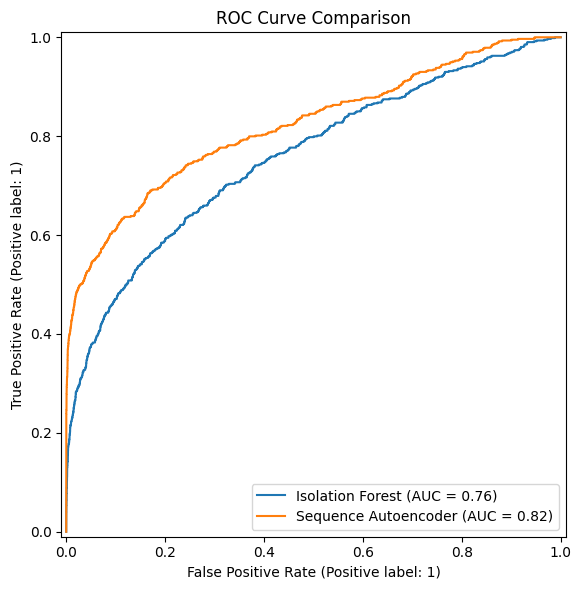

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test_if, if_model.anomaly_scores(X_test_if), ax=ax, name='Isolation Forest')
RocCurveDisplay.from_predictions(y_test_ae, ae_model.anomaly_scores(X_test_ae), ax=ax, name='Sequence Autoencoder')
ax.set_title('ROC Curve Comparison')
plt.tight_layout(); plt.savefig('../results/roc_curve.png', dpi=100); plt.show()

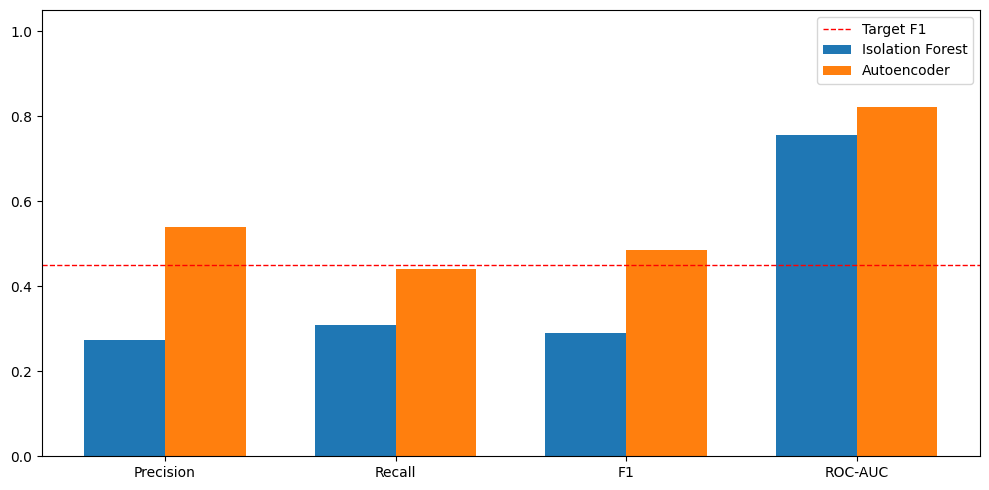

In [10]:
metrics_names = ['precision', 'recall', 'f1', 'roc_auc']
x = np.arange(len(metrics_names)); width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, [if_metrics[m] for m in metrics_names], width, label='Isolation Forest')
ax.bar(x + width/2, [ae_metrics[m] for m in metrics_names], width, label='Autoencoder')
ax.axhline(0.45, color='red', linestyle='--', lw=1, label='Target F1')
ax.set_xticks(x); ax.set_xticklabels(['Precision', 'Recall', 'F1', 'ROC-AUC'])
ax.set_ylim(0, 1.05); ax.legend()
plt.tight_layout(); plt.savefig('../results/model_comparison.png', dpi=100); plt.show()